# DATASET
https://www.kaggle.com/datasets/techsash/waste-classification-data

This dataset is for performing image classification on the trash

# Procedure

Perform Training and Validation using the following techniques:

1. CNN

2. CNN with Regularization

3. Transfer Learning (feature transfer )

4. Transfer Learning (fine-tuning)

Plot the accuracy for every 10 epochs for both Training and Validation.

Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity)

Plot the ROC AUC score result of the model

Interpret and evaluate the result of the model.

Include a conclusion/summary of the activity.

Submit a PDF of the IPYNB and an accessible link.

## Loading Dataset

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path
train_dir = r"waste\TRAIN"
test_dir  = r"waste\TEST"

img_height, img_width = 256, 256
batch_size = 8
val_split = 0.2


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Info
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Train samples: 18052
Validation samples: 4512
Test samples: 2513


AUGMENTATION

## 1. CNN

In [2]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(img_height, img_width, 3))
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)


x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)


outputs = Dense(1, activation='sigmoid')(x)

# Model
model = Model(inputs=inputs, outputs=outputs)


In [3]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',  # ✅ fixed spelling
    metrics=['accuracy']
)


In [4]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 conv2d_2 (Conv2D)           (None, 128, 128, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 64, 64, 64)       0         
 2D)                                                         

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [6]:
ballers1 = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 8,
    callbacks=[early_stop]
)

Epoch 1/100
2257/2257 [==============================] - 198s 31ms/step - loss: 0.4673 - accuracy: 0.7947 - val_loss: 0.4868 - val_accuracy: 0.7906
Epoch 2/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3941 - accuracy: 0.8353 - val_loss: 0.3776 - val_accuracy: 0.8378
Epoch 3/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3642 - accuracy: 0.8509 - val_loss: 0.3601 - val_accuracy: 0.8391
Epoch 4/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3508 - accuracy: 0.8585 - val_loss: 0.3457 - val_accuracy: 0.8455
Epoch 5/100
2257/2257 [==============================] - 69s 30ms/step - loss: 0.3332 - accuracy: 0.8679 - val_loss: 0.3210 - val_accuracy: 0.8639
Epoch 6/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3202 - accuracy: 0.8746 - val_loss: 0.3188 - val_accuracy: 0.8721
Epoch 7/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3113 - accuracy: 0.8773 - val_loss: 

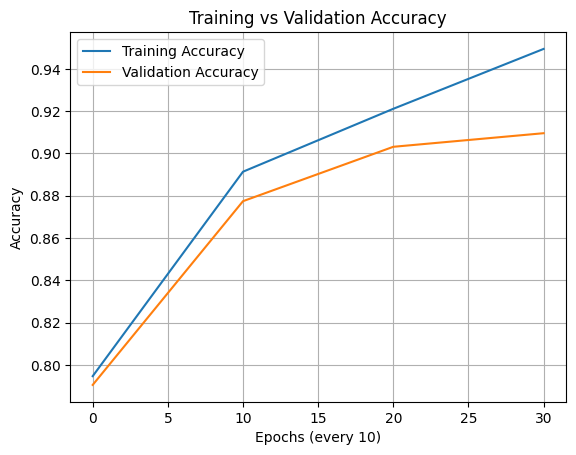

In [7]:
import matplotlib.pyplot as plt

acc = ballers1.history['accuracy']
val_acc = ballers1.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

The model overfits based on the figure output above because the accuracy of the model on the validation is not going up in further epochs while the training accuracy keeps climbing.

In [8]:
import numpy as np

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

315/315 [==============================] - 3s 8ms/step


ROC-AUC

315/315 [==============================] - 2s 8ms/step


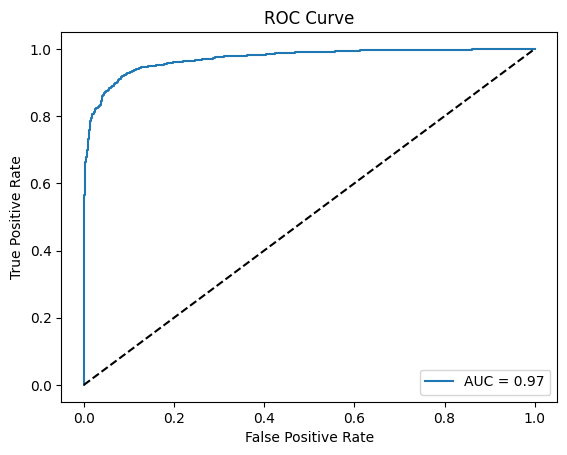

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Get probabilities (flatten to 1D)
y_pred_probs = model.predict(test_generator).ravel()

# True labels
y_true = test_generator.classes

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

CONFUSION MATRIX

In [16]:
class_labels = list(test_generator.class_indices.keys())

In [17]:
y_pred_probs = model.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

315/315 [==============================] - 2s 7ms/step


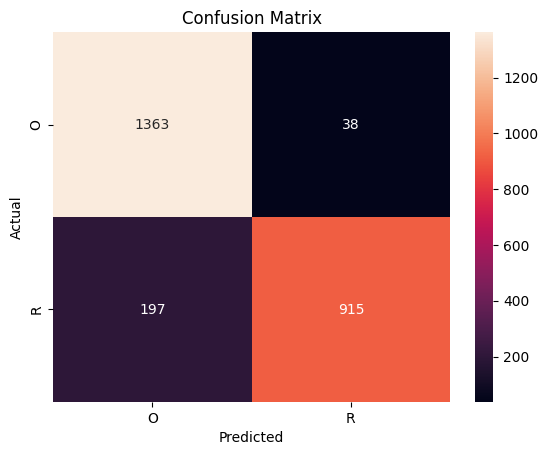

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

CLASSIFICATION REPORT

In [19]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.87      0.97      0.92      1401
           R       0.96      0.82      0.89      1112

    accuracy                           0.91      2513
   macro avg       0.92      0.90      0.90      2513
weighted avg       0.91      0.91      0.91      2513



Based on the classification report the model i unable to recognize the different balls in the dataset. This is due to the low precision and recall score and the accuracy of the model. We can see that the model did not learn enough of the balls data.

## 2. CNN with Regularization (WITH AUGMENTATION)

In [70]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = r"waste\TRAIN"
test_dir  = r"waste\TEST"

img_height, img_width = 256, 256
batch_size = 16
val_split = 0.2

# TRAIN (with strong augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split,

    rotation_range=40,              # rotate trash images
    width_shift_range=0.4,          # horizontal shift
    height_shift_range=0.4,         # vertical shift
    zoom_range=0.2,                 # zoom in/out
    horizontal_flip=True,           # flip objects
    vertical_flip=True,             # useful for trash (orientation doesn't matter)
    brightness_range=[0.7, 2.0],    # lighting variation
    channel_shift_range=20.0,       # color variation
    fill_mode='nearest'
)

# TEST (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Info
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Train samples: 18052
Validation samples: 4512
Test samples: 2513


Here I used l2 penalty, batch normalization and dropouts in order to have regularization on each of the blocks for the model. I used this since this is one of the common regularization techniques for models.

In [71]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Input
inputs = Input(shape=(img_height, img_width, 3))

# Block 1
x = Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(0.0001))(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# Block 2
x = Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(0.0001))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# Block 3
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# Block 4
x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# Fully Connected
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

# Output
outputs = Dense(1, activation='sigmoid')(x)
# Model
model2 = Model(inputs=inputs, outputs=outputs)

# Compile
model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [72]:
model2.summary()

Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 256, 256, 3)]     0         
                                                                 
 conv2d_94 (Conv2D)          (None, 256, 256, 32)      896       
                                                                 
 batch_normalization_72 (Bat  (None, 256, 256, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_60 (MaxPoolin  (None, 128, 128, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_95 (Conv2D)          (None, 128, 128, 64)      18496     
                                                                 
 conv2d_96 (Conv2D)          (None, 128, 128, 64)      369

In [73]:
ballers2 = model2.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 16,
    callbacks=[early_stop]
)


Epoch 1/100
1129/1129 [==============================] - 317s 280ms/step - loss: 0.5228 - accuracy: 0.7716 - val_loss: 0.4689 - val_accuracy: 0.7932
Epoch 2/100
1129/1129 [==============================] - 237s 210ms/step - loss: 0.4673 - accuracy: 0.7961 - val_loss: 0.4524 - val_accuracy: 0.8072
Epoch 3/100
1129/1129 [==============================] - 171s 151ms/step - loss: 0.4340 - accuracy: 0.8154 - val_loss: 0.4263 - val_accuracy: 0.8047
Epoch 4/100
1129/1129 [==============================] - 166s 147ms/step - loss: 0.4277 - accuracy: 0.8176 - val_loss: 0.4456 - val_accuracy: 0.8149
Epoch 5/100
1129/1129 [==============================] - 165s 146ms/step - loss: 0.4151 - accuracy: 0.8248 - val_loss: 0.4705 - val_accuracy: 0.7861
Epoch 6/100
1129/1129 [==============================] - 166s 147ms/step - loss: 0.4081 - accuracy: 0.8297 - val_loss: 0.5499 - val_accuracy: 0.7493
Epoch 7/100
1129/1129 [==============================] - 165s 146ms/step - loss: 0.4051 - accuracy: 0.8318

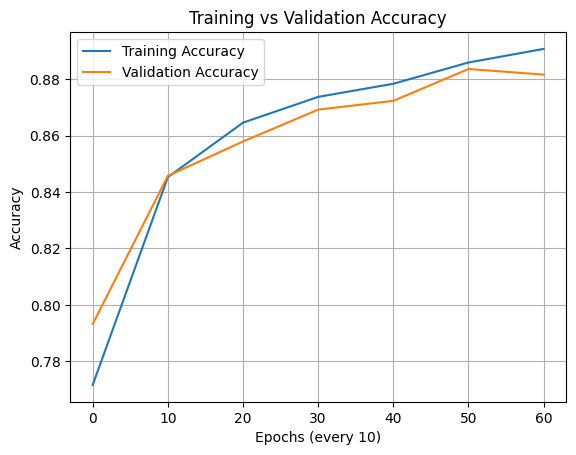

In [74]:
import matplotlib.pyplot as plt

acc = ballers2.history['accuracy']
val_acc = ballers2.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

ROC-AUC

158/158 [==============================] - 3s 17ms/step


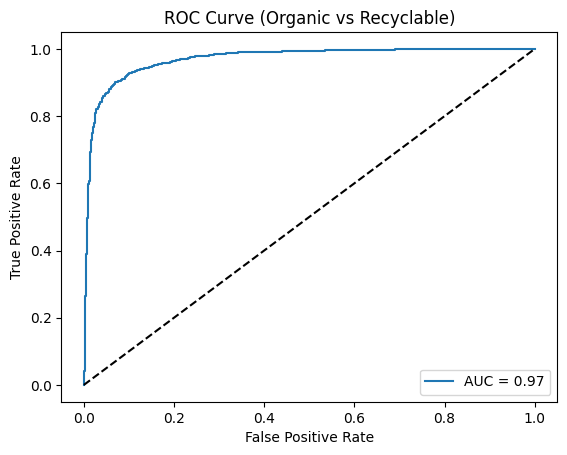

In [79]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Get probabilities (flatten to 1D)
y_pred_probs = model2.predict(test_generator).ravel()

# True labels
y_true = test_generator.classes

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Organic vs Recyclable)")
plt.legend()
plt.show()

CONFUSION MATRIX

In [80]:
y_pred_probs = model2.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

158/158 [==============================] - 3s 17ms/step


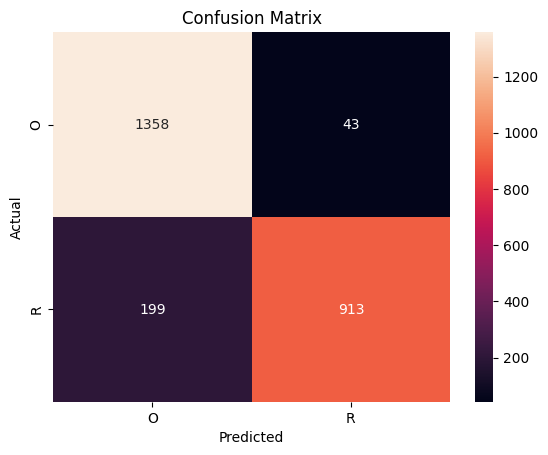

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

CLASSIFICATION REPORT

In [82]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.87      0.97      0.92      1401
           R       0.96      0.82      0.88      1112

    accuracy                           0.90      2513
   macro avg       0.91      0.90      0.90      2513
weighted avg       0.91      0.90      0.90      2513



## 3. Transfer Learning (feature transfer )

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path
train_dir = r"waste\TRAIN"
test_dir  = r"waste\TEST"

img_height, img_width = 299, 299
batch_size = 8
val_split = 0.2


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Info
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Train samples: 18052
Validation samples: 4512
Test samples: 2513


Using ResNet50

In [3]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(img_height, img_width, 3))
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(1, activation='sigmoid')(x)
model3 = Model(inputs=inputs, outputs=outputs)

model3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 149, 149, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_94 (BatchN  (None, 149, 149, 32  96         ['conv2d_94[0][0]']              
 ormalization)                  )                                                             

In [6]:
res = model3.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 8,
    callbacks = [early_stop]
)

Epoch 1/100
2257/2257 [==============================] - 92s 39ms/step - loss: 0.2314 - accuracy: 0.9089 - val_loss: 0.1634 - val_accuracy: 0.9346
Epoch 2/100
2257/2257 [==============================] - 91s 40ms/step - loss: 0.1716 - accuracy: 0.9339 - val_loss: 0.1392 - val_accuracy: 0.9501
Epoch 3/100
2257/2257 [==============================] - 94s 41ms/step - loss: 0.1532 - accuracy: 0.9424 - val_loss: 0.1373 - val_accuracy: 0.9501
Epoch 4/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1427 - accuracy: 0.9463 - val_loss: 0.1431 - val_accuracy: 0.9477
Epoch 5/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1266 - accuracy: 0.9518 - val_loss: 0.1457 - val_accuracy: 0.9515
Epoch 6/100
2257/2257 [==============================] - 92s 41ms/step - loss: 0.1188 - accuracy: 0.9560 - val_loss: 0.1424 - val_accuracy: 0.9506
Epoch 7/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1113 - accuracy: 0.9579 - val_loss: 0

ACCURACY PLOT

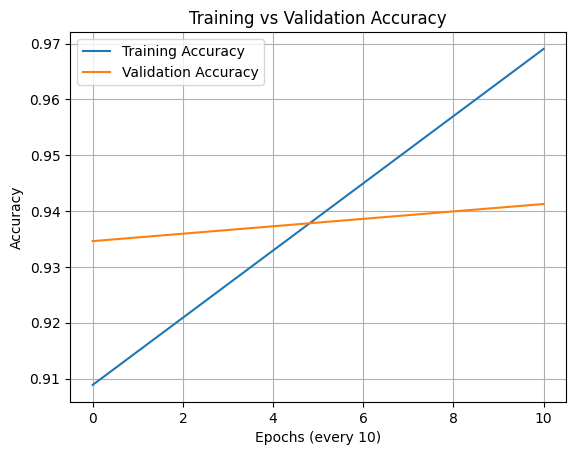

In [7]:
import matplotlib.pyplot as plt

acc = res.history['accuracy']
val_acc = res.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

ROC-AUC

315/315 [==============================] - 10s 29ms/step


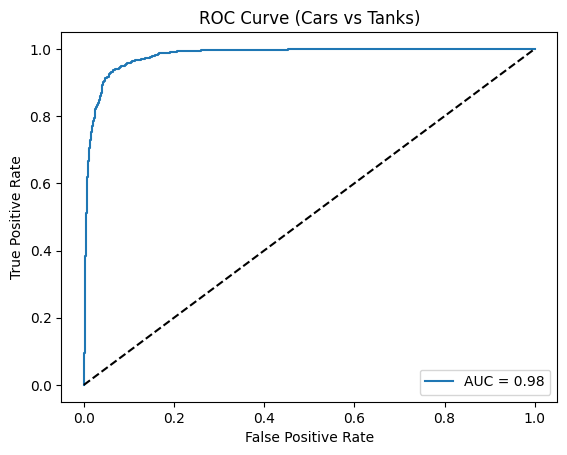

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = model3.predict(test_generator).ravel()
y_true = test_generator.classes

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Cars vs Tanks)")
plt.legend()
plt.show()

CONFUSION MATRIX

In [9]:
y_pred_probs = model3.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

315/315 [==============================] - 9s 28ms/step


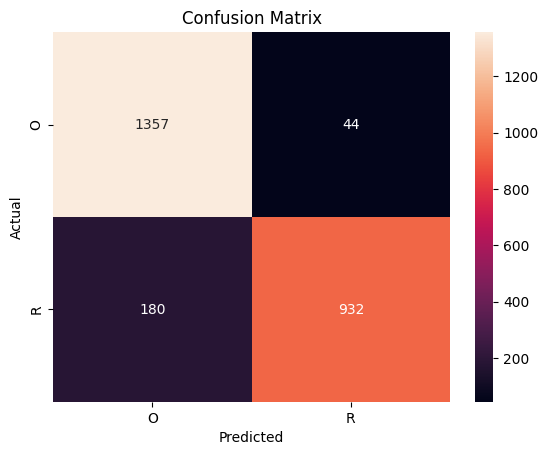

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_generator.class_indices.keys())

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

CLASSIFICATION REPORT

In [11]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.88      0.97      0.92      1401
           R       0.95      0.84      0.89      1112

    accuracy                           0.91      2513
   macro avg       0.92      0.90      0.91      2513
weighted avg       0.91      0.91      0.91      2513



## 4. Transfer Learning (fine-tuning)

In [21]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Model
model4 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


model4.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model4.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 8, 8, 2048)        21802784  
                                                                 
 global_average_pooling2d_5   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_9 (Dense)             (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 1)                 129       
                                                                 
Total params: 22,065,185
Trainable params: 7,435,713
Non-trainable params: 14,629,472
__________________________________

In [22]:
res2 = model4.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 64,
    callbacks = [early_stop]
)

Epoch 1/100
2257/2257 [==============================] - 92s 40ms/step - loss: 0.2085 - accuracy: 0.9207 - val_loss: 0.1261 - val_accuracy: 0.9508
Epoch 2/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1235 - accuracy: 0.9550 - val_loss: 0.1993 - val_accuracy: 0.9260
Epoch 3/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0757 - accuracy: 0.9762 - val_loss: 0.2698 - val_accuracy: 0.9153
Epoch 4/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0550 - accuracy: 0.9820 - val_loss: 0.1812 - val_accuracy: 0.9515
Epoch 5/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0438 - accuracy: 0.9857 - val_loss: 0.2042 - val_accuracy: 0.9441
Epoch 6/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0340 - accuracy: 0.9904 - val_loss: 0.2921 - val_accuracy: 0.9227
Epoch 7/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0277 - accuracy: 0.9915 - val_loss: 0

ACCURACY PLOT

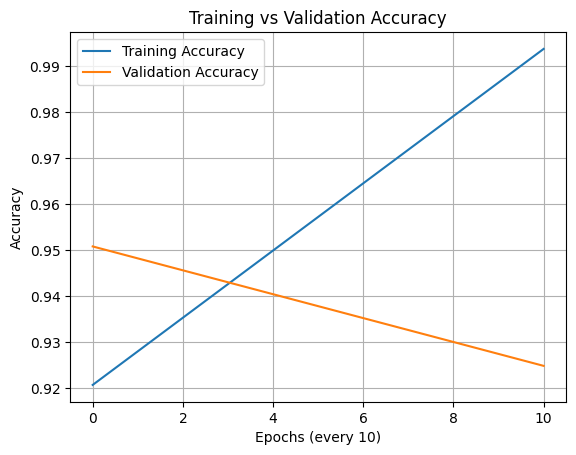

In [23]:
import matplotlib.pyplot as plt

acc = res2.history['accuracy']
val_acc = res2.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

ROC-AUC

315/315 [==============================] - 9s 26ms/step


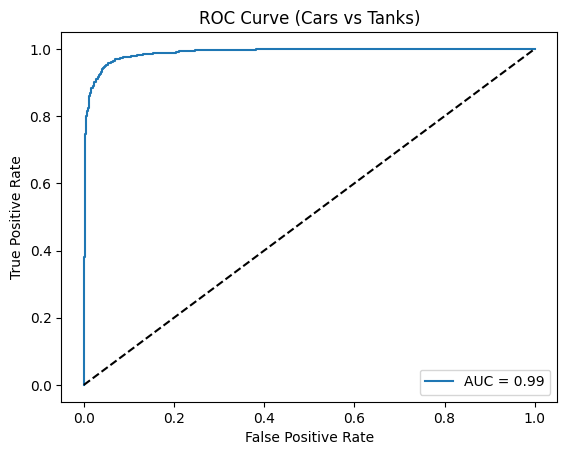

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Get probabilities (flatten to 1D)
y_pred_probs = model4.predict(test_generator).ravel()

# True labels
y_true = test_generator.classes

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Cars vs Tanks)")
plt.legend()
plt.show()

CONFUSION MATRIX

In [25]:
y_pred_probs = model4.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

315/315 [==============================] - 8s 26ms/step


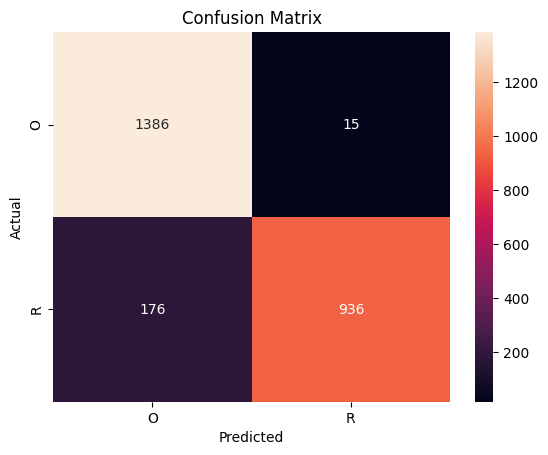

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

CLASSIFICATION REPORT

In [27]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.89      0.99      0.94      1401
           R       0.98      0.84      0.91      1112

    accuracy                           0.92      2513
   macro avg       0.94      0.92      0.92      2513
weighted avg       0.93      0.92      0.92      2513

